# وَأَن لَّيْسَ لِلْإِنسَانِ إِلَّا مَا سَعَىٰ (39) وَأَنَّ سَعْيَهُ سَوْفَ يُرَىٰ (40) ثُمَّ يُجْزَاهُ الْجَزَاءَ الْأَوْفَىٰ

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

data_path=[]

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       data_path.append(os.path.join(dirname, filename))
        
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
data_path


['/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv',
 '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv']

In [4]:
customers=data_path[0]
sellers=data_path[1]
review=data_path[2]
items=data_path[3]
products=data_path[4]
geolocation=data_path[5]
category_name_translation=data_path[6]
orders=data_path[7]
order_payments=data_path[8]

In [5]:
customers = pd.read_csv(customers)
sellers = pd.read_csv(sellers)
review = pd.read_csv(review)
items = pd.read_csv(items)
products = pd.read_csv(products)
geolocation = pd.read_csv(geolocation)
category_name_translation = pd.read_csv(category_name_translation)
orders = pd.read_csv(orders)
order_payments = pd.read_csv(order_payments)
datasets=[customers,sellers,review,items,products,geolocation,category_name_translation,orders,order_payments]

In [6]:
"""for data in datasets:
    print(data.describe())
    print("\n===================================\n")"""

'for data in datasets:\n    print(data.describe())\n    print("\n===================================\n")'

In [7]:
datasets=[customers,sellers,review,items,products,geolocation,category_name_translation,orders,order_payments]
"""for data in datasets:
    print(data.info())
    print("")
    print(f"Null Values= {data.isnull().sum()}")
    print("")
    print(f"Duplicated Values= {data.duplicated().sum()}")

    print("\n===================================\n")
"""

'for data in datasets:\n    print(data.info())\n    print("")\n    print(f"Null Values= {data.isnull().sum()}")\n    print("")\n    print(f"Duplicated Values= {data.duplicated().sum()}")\n\n    print("\n===================================\n")\n'

# Data Preperation

## 1- Feature engineering 

In [8]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

In [9]:
orders['org_to_carrier_time'] = orders['order_delivered_carrier_date'] - orders['order_approved_at']
orders['carrier_to_customer_time'] = orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
orders['actual_arrival_time'] = orders['order_delivered_customer_date'] - orders['order_approved_at']
orders['apply_SLA'] = orders['order_delivered_customer_date'] <= orders['order_estimated_delivery_date']
orders['delivery_delay']= orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']

# Data Overview

## 1- What is the total number of requests in the data?

In [10]:
orders['order_id'].nunique()

99441

In [11]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 2- Customers distribution in each city

## 3- Total orders in each state

In [12]:
customer_with_orders=pd.merge(customers,orders,on="customer_id")

orders_with_state=customer_with_orders.groupby("customer_state")["order_id"].count().sort_values(ascending=False).head(10)
orders_with_state

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

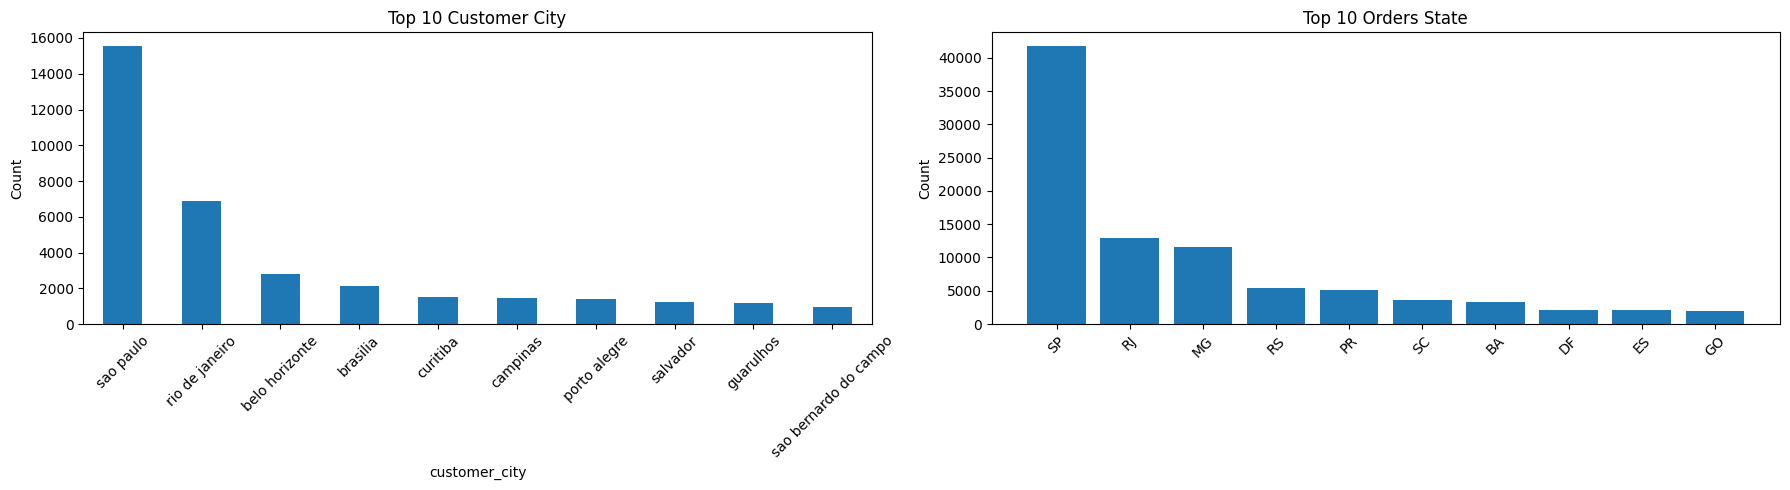

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(18,5))

customers['customer_city'].value_counts().head(10).plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Top 10 Customer City")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(
    orders_with_state.index,
    orders_with_state.values
)
axes[1].set_title("Top 10 Orders State")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. Most customers are concentrated in a few major cities. São Paulo has the highest number of customers (15,540), followed by Rio de Janeiro and Belo Horizonte. Although customers come from 4,119 cities, many cities have only one customer, indicating a wide but uneven geographic distribution.

2. Demand is significantly higher in a few states. São Paulo (SP) dominates the platform with the largest number of orders, followed by Rio de Janeiro (RJ) and Minas Gerais (MG), showing that most e-commerce activity is concentrated in Brazil’s southeastern region.

## 4- Best-selling categories

In [14]:
selling_categories=products["product_category_name"].value_counts().head(10)
selling_categories

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

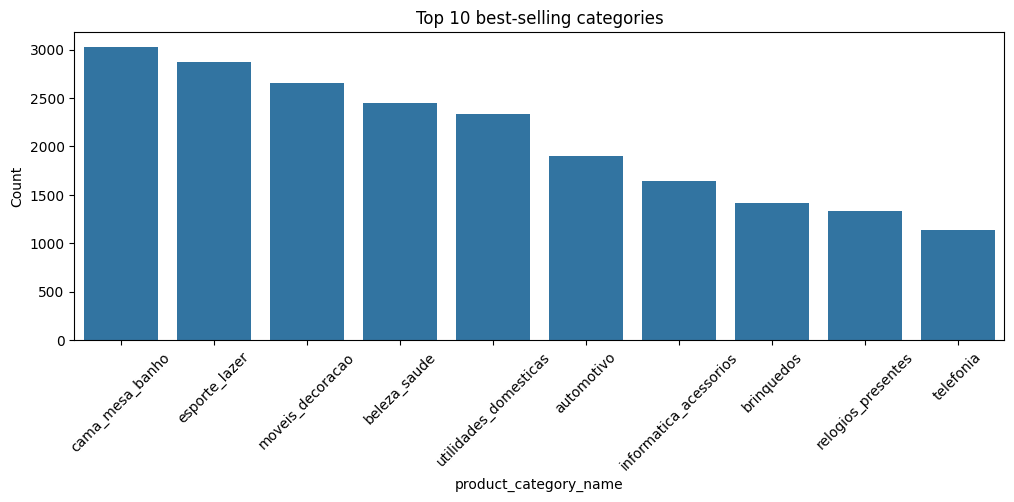

In [15]:
plt.figure(figsize=(12,4))
sns.barplot(selling_categories)
plt.title("Top 10 best-selling categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The best-selling product categories are dominated by home and lifestyle-related items. Categories such as cama_mesa_banho (bed, table, bath), esporte_lazer (sports & leisure), and moveis_decoracao (furniture & decoration) lead the sales, indicating strong customer demand for household and everyday lifestyle products.

## 5- Are there categories that experience longer delivery times than others?

In [16]:
items_products=pd.merge(items,products,on="product_id")
order_items_products=pd.merge(orders,items_products,on="order_id") 


In [17]:
order_items_products["delivery_time"] = (
    order_items_products["order_delivered_customer_date"]
    - order_items_products["order_purchase_timestamp"]
)

category_delivery = (
    order_items_products
    .groupby("product_category_name")["delivery_time"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_delivery

product_category_name
moveis_escritorio                20 days 20:11:41.211630695
artigos_de_natal                 15 days 17:46:35.093333333
fashion_calcados                 15 days 10:35:32.964980544
seguros_e_servicos                  15 days 03:18:56.500000
casa_conforto_2                     14 days 13:45:52.600000
moveis_colchao_e_estofado        14 days 10:23:28.567567567
eletrodomesticos_2                         13 days 21:45:17
moveis_sala                      13 days 19:04:51.040404040
ferramentas_jardim               13 days 17:00:47.386597938
fashion_underwear_e_moda_praia   13 days 16:57:06.551181102
Name: delivery_time, dtype: timedelta64[ns]

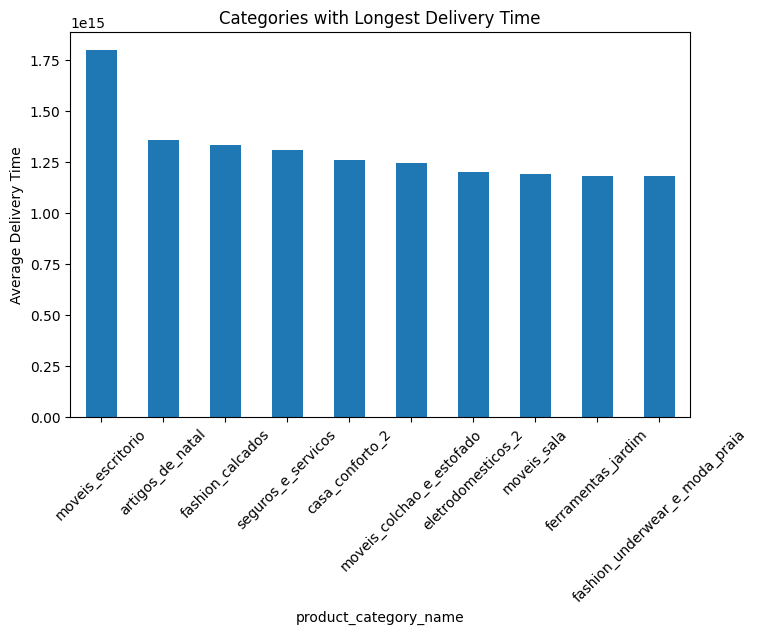

In [18]:
category_delivery.plot(kind="bar", figsize=(8,5))

plt.title("Categories with Longest Delivery Time")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=45)

plt.show()

Some product categories have longer delivery times than others. Office furniture (moveis_escritorio) shows the longest average delivery time (~21 days), likely due to the large size and complex shipping requirements of furniture products.


## 6- What percentage of customers placed more than one order?

In [19]:
customer_orders=customer_with_orders.groupby("customer_unique_id")["order_id"].count()
repeat_customer=customer_orders[customer_orders>1]
percentage=(len(repeat_customer)/len(customer_orders))*100
print(f"percentage {percentage}")

percentage 3.1187562437562435


Only about 3.12% of customers placed more than one order. This indicates that the majority of customers on the platform are one-time buyers, suggesting relatively low customer retention.

## 7- How many orders have already been delivered?

In [20]:
print(orders['order_status'].value_counts()[0])

96478


/tmp/ipykernel_55/561560311.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(orders['order_status'].value_counts()[0])


## 8- What is the average actual delivery time?

In [21]:
orders['actual_arrival_time'].mean()

Timedelta('12 days 03:07:42.855694470')

# SLA Compliance

## 1- How many orders were delivered on time?

In [22]:
sla_true=orders[orders['apply_SLA']==True].shape[0]
sla_true

88649

## 2- How many orders were delayed beyond the expected date?

In [23]:
sla_false=orders[orders['apply_SLA']==False].shape[0]
sla_false

10792

## 3- What is the compliance rate with the SLA?

In [24]:
sla_rate=(sla_true/(sla_false+sla_true))*100
sla_rate

89.14733359479492

The SLA compliance rate is 88.14%, meaning that the majority of orders were delivered within the estimated delivery time. However, approximately 11.86% of orders were delivered late, indicating potential opportunities to improve logistics performance.

## 4- What is the average number of days of delay?

In [25]:
orders['delivery_delay'].mean()


Timedelta('-12 days +19:42:04.042383598')

The average delivery delay is -12 days, indicating that orders are typically delivered significantly earlier than the estimated delivery date.

## 5- What is the maximum delay that occurred in the data?

In [26]:
orders['delivery_delay'].max()

Timedelta('188 days 23:24:07')

The maximum delivery delay recorded in the dataset is approximately 188 days, indicating an extreme outlier that may represent a significant logistics issue or a data anomaly.

## 6- States with the most delivery delays

In [27]:
state_with_delay=customer_with_orders[customer_with_orders['apply_SLA']==False].groupby("customer_state")['apply_SLA'].count().sort_values(ascending=False).head(10)
state_with_delay

customer_state
SP    3638
RJ    2163
MG     918
BA     581
RS     504
SC     436
PR     368
ES     282
CE     253
PE     231
Name: apply_SLA, dtype: int64

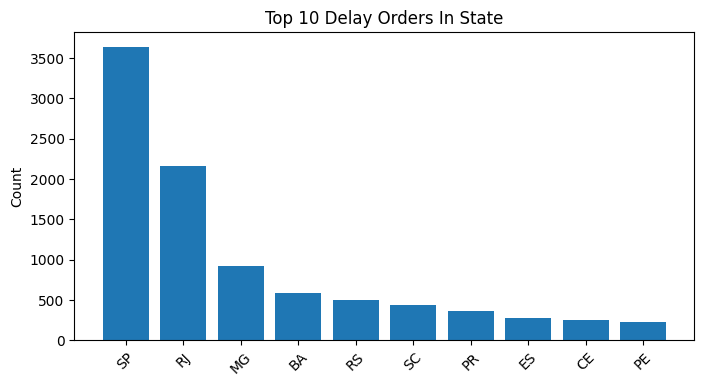

In [28]:
plt.figure(figsize=(8,4))
plt.bar(state_with_delay.index,height=state_with_delay.values)
plt.title("Top 10 Delay Orders In State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Delivery delays are most common in SP (São Paulo) with 3,638 delayed orders, followed by RJ (Rio de Janeiro) and MG (Minas Gerais). This suggests that states with the highest order volumes also tend to experience more delivery delays, possibly due to heavier logistics demand.

## 7- Most delay product in each state

In [29]:
items_products = pd.merge(items, products, on="product_id")

orders_customers = pd.merge(orders, customers, on="customer_id")

order_items_products = pd.merge(orders_customers,items_products,on="order_id")

order_items_products["delay"] = (order_items_products["order_delivered_customer_date"] -order_items_products["order_estimated_delivery_date"]).dt.days


delayed = order_items_products[order_items_products["delay"] > 0].copy()


grouped = delayed.groupby(["customer_state", "product_category_name"])["delay"].mean().reset_index()


idx = grouped.groupby("customer_state")["delay"].idxmax()

result = grouped.loc[idx].sort_values("delay", ascending=False)


print(result)

    customer_state              product_category_name       delay
614             SE              instrumentos_musicais  166.000000
32              AP                   moveis_decoracao  144.000000
501             RN                      casa_conforto  137.000000
528             RR                      esporte_lazer  132.000000
27              AM                          alimentos  104.000000
237             MG                 eletrodomesticos_2   84.000000
316             PA                     consoles_games   60.666667
191             GO              utilidades_domesticas   59.000000
557             RS                  moveis_escritorio   55.333333
448             RJ                            bebidas   49.000000
594             SC          moveis_colchao_e_estofado   48.000000
299             MT                  moveis_escritorio   39.500000
397             PI                  moveis_escritorio   36.400000
75              CE                   artigos_de_natal   35.000000
137       

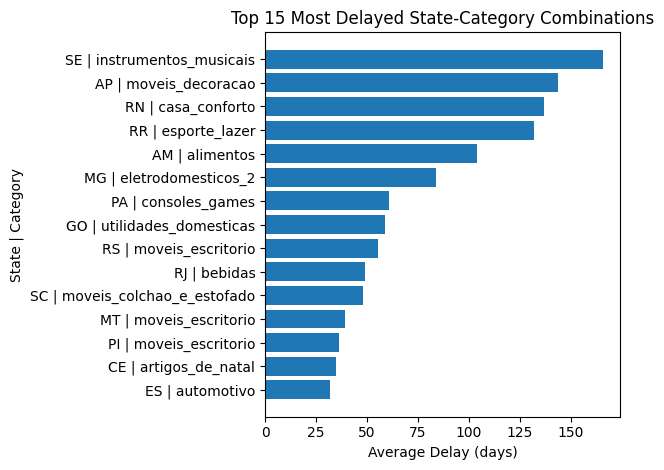

In [30]:
result = grouped.loc[idx].sort_values("delay", ascending=False)
df = result.copy()

df = df.sort_values("delay", ascending=True).tail(15)

labels = df["customer_state"] + " | " + df["product_category_name"]

plt.figure()
plt.barh(labels, df["delay"])
plt.xlabel("Average Delay (days)")
plt.ylabel("State | Category")
plt.title("Top 15 Most Delayed State-Category Combinations")
plt.tight_layout()
plt.show()

Delivery delay is not uniformly distributed. It is strongly influenced by geographic distance and product category characteristics (size, weight, and handling complexity), rather than state alone.

# Geographic Performance

## 1- Which states have the highest delay rates?

In [31]:
order_with_customer=pd.merge(customers,orders,on="customer_id")


In [32]:
delay_with_state=order_with_customer.groupby("customer_state")['apply_SLA'].mean().sort_values(ascending=True)
print(delay_with_state)

customer_state
AL    0.731235
MA    0.771084
RR    0.782609
PI    0.808081
CE    0.810629
SE    0.811429
BA    0.828107
RJ    0.831699
PA    0.850256
TO    0.853571
PB    0.858209
PE    0.860169
ES    0.861289
MS    0.867133
RN    0.872165
SC    0.880121
GO    0.889604
DF    0.903271
RS    0.907794
MT    0.910695
SP    0.912854
MG    0.921100
PR    0.927056
RO    0.932806
AM    0.939189
AP    0.941176
AC    0.950617
Name: apply_SLA, dtype: float64


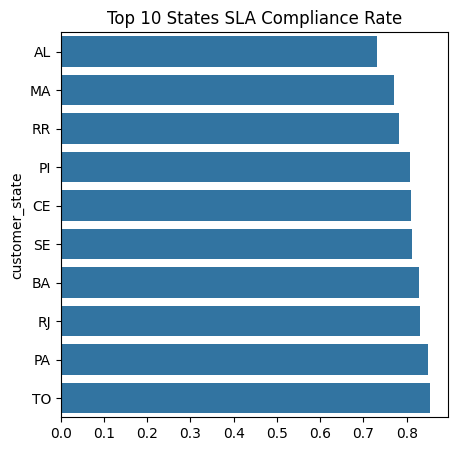

In [33]:
plt.figure(figsize=(5,5))
sns.barplot(x=delay_with_state.head(10).values,y=delay_with_state.head(10).index)
plt.title("Top 10 States SLA Compliance Rate")
plt.show()

States such as AL and MA show the lowest SLA compliance rates (around 73–77%), indicating significant delivery delays compared to other regions. This may be related to logistical challenges or longer shipping distances.

## 2- Which states have the best delivery performance?

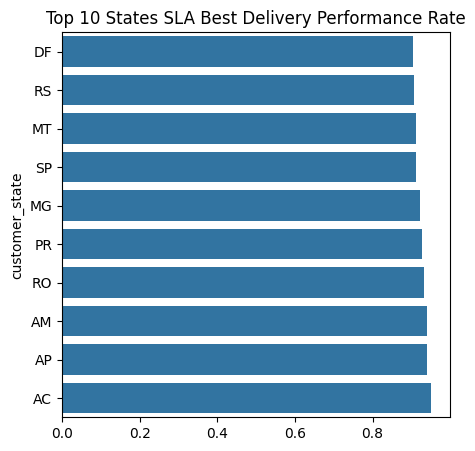

In [34]:
plt.figure(figsize=(5,5))
sns.barplot(x=delay_with_state.tail(10).values,y=delay_with_state.tail(10).index)
plt.title("Top 10 States SLA Best Delivery Performance Rate")
plt.show()

States such as AC, AP, and AM show the highest SLA compliance rates, exceeding 93%, indicating highly efficient delivery performance in these regions.

# Delivery Time Analysis

## 1- Average actual delivery time vs estimated

In [35]:
orders["estimated_delivery_time"] = (orders["order_estimated_delivery_date"] - orders["order_approved_at"])
print("Actual Delivery Time",orders['actual_arrival_time'].mean())
print("Estimated Time",orders['estimated_delivery_time'].mean())


Actual Delivery Time 12 days 03:07:42.855694470
Estimated Time 23 days 08:01:22.510722092


The average actual delivery time is approximately 12 days, while the estimated delivery time is around 23 days, indicating that orders are typically delivered about 11 days earlier than expected. This suggests that the delivery estimates include a significant buffer to ensure SLA compliance.

## 2- Distribution of delivery times

In [36]:
orders['delivery_Days'] = orders['actual_arrival_time'].dt.days
within_5_days=(orders['delivery_Days']<=5).mean()*100
within_10_days=(orders['delivery_Days']<=10).mean()*100
within_15_days=(orders['delivery_Days']<=15).mean()*100
within_20_days=(orders['delivery_Days']<=20).mean()*100



In [37]:
print(f"Delivered within 5 days: {within_5_days:.2f}%")
print(f"Delivered within 10 days: {within_10_days:.2f}%")
print(f"Delivered within 15 days: {within_15_days:.2f}%")
print(f"Delivered within 20 days: {within_20_days:.2f}%")

Delivered within 5 days: 21.74%
Delivered within 10 days: 54.89%
Delivered within 15 days: 75.13%
Delivered within 20 days: 85.19%


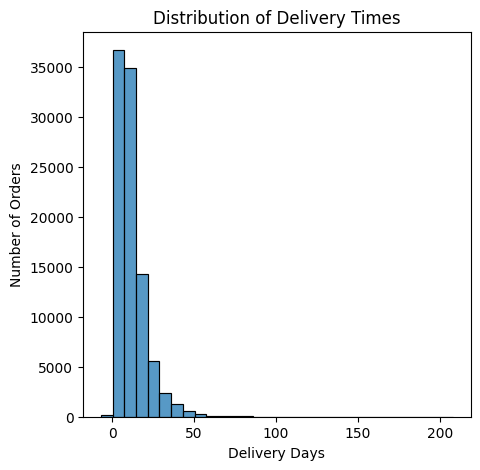

In [38]:
plt.figure(figsize=(5,5))
sns.histplot(orders["delivery_Days"], bins=30)

plt.title("Distribution of Delivery Times")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.show()

The delivery time distribution shows that over 54% of orders are delivered within 10 days, while 75% arrive within 15 days. This indicates that most deliveries are completed within two weeks, demonstrating relatively efficient logistics performance.

## 3- Trend over time

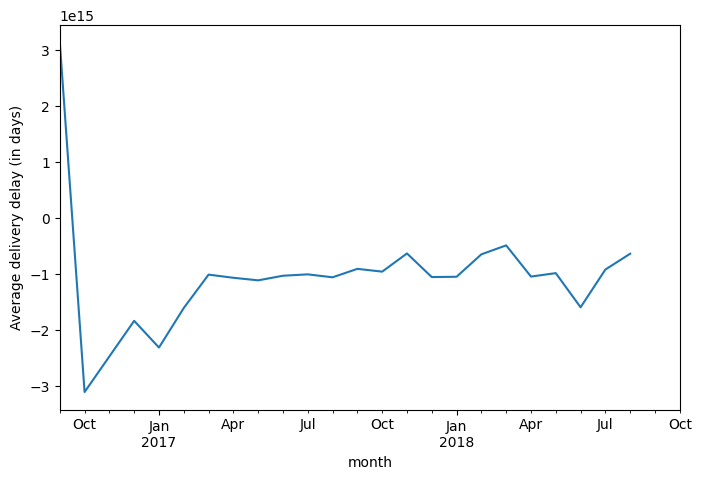

In [39]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
plt.figure(figsize=(8,5))
trend = orders.groupby('month')['delivery_delay'].mean()
trend.plot(kind='line')
plt.ylabel("Average delivery delay (in days)")
plt.show()

The monthly trend of delivery delay shows consistently negative values, indicating that orders are delivered significantly earlier than estimated across all months. This suggests that delivery estimates are conservative and include a large safety buffer rather than reflecting actual logistics performance.

# Seller Impact

## 1- Top 10 sellers with delays [With at least 10 orders]

In [40]:
orders_with_items=pd.merge(orders,items,on="order_id")

In [41]:
seller_orders = orders_with_items.groupby('seller_id')['order_id'].count()
seller_delay = orders_with_items.groupby('seller_id')['delivery_delay'].mean()

seller_analysis = pd.concat([seller_orders, seller_delay], axis=1)
seller_analysis.columns = ['num_orders', 'avg_delay']

seller_analysis['avg_delay_days'] = seller_analysis['avg_delay'].dt.total_seconds() / (24 * 3600)

In [42]:
top_delayed_sellers = seller_analysis[seller_analysis['num_orders'] > 10]
top_delayed_sellers.sort_values('avg_delay', ascending=False).head(10)


,num_orders,avg_delay,avg_delay_days
seller_id,,,
cb41bfbcbda0aea354a834ab222f9a59,12,10 days 07:11:54.636363636,10.299938
c42fd8e4d47dfb18ce5222f2dd7752f9,11,10 days 02:58:54.636363636,10.124243
b1b3948701c5c72445495bd161b83a4c,18,4 days 17:41:48.928571428,4.737372
b0b346d3a89f5eb4c2968af3f083cd43,12,3 days 05:49:45.666666666,3.242890
2a1348e9addc1af5aaa619b1a3679d6b,55,1 days 08:29:42.215686274,1.353961
c990d6cf976a5718aaedc539f383ab88,11,0 days 20:16:12.111111111,0.844585
26e2c91ef821e1ff8985f408788fe35b,14,0 days 01:23:29.428571428,0.057979
5f67c6082caacb26e431a7b17940cece,14,-2 days +21:06:11.071428572,-1.120705
b5abf4f36adc043117b4fca82c22984c,12,-2 days +17:14:12.444444445,-1.281800


Most sellers deliver on time or even earlier than expected, but a few sellers show significant delays (up to ~10 days). These sellers are likely the main contributors to overall delivery performance issues.

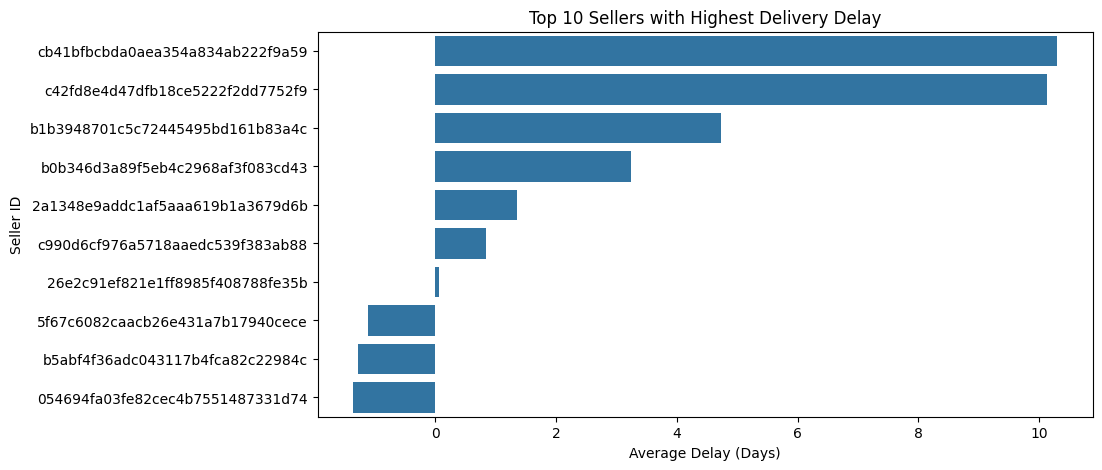

In [43]:

plt.figure(figsize=(10,5))

top10 = top_delayed_sellers.sort_values("avg_delay", ascending=False).head(10)

sns.barplot(
    x=top10["avg_delay"].dt.total_seconds()/(24*3600),
    y=top10.index
)

plt.title("Top 10 Sellers with Highest Delivery Delay")
plt.xlabel("Average Delay (Days)")
plt.ylabel("Seller ID")

plt.show()

## 2- Top 10 Sellers with Earliest Delivery

In [44]:
top_delivary_sellers=top_delayed_sellers.sort_values("avg_delay", ascending=False).tail(10)
top_delivary_sellers

,num_orders,avg_delay,avg_delay_days
seller_id,,,
c8c1bea22194a4eefa2dc9a9fa89f536,13,-24 days +00:32:07.923076923,-23.977686
bdae679a9b282249bc23b9b69dae9a99,12,-25 days +21:26:46.333333334,-24.106408
bfd938b22bc99bce1ae60dc602889f52,12,-25 days +07:27:59.333333334,-24.688897
817f85dbb65aa3e70831d90fe75cdf89,11,-25 days +01:35:58.181818182,-24.933354
3092c0b297aacfb4bb6e056ebe13b9b8,21,-27 days +17:30:46.647058824,-26.270293
ed859002ad59dbf8cf3602696a6c3000,13,-28 days +05:10:08.181818182,-27.784628
8a87611c08849ffeeccab52aa798b6c7,14,-30 days +12:27:58.500000,-29.480573
c9a06ece156bb057372c68718ec8909b,14,-33 days +14:54:24.272727273,-32.378886
b92e3c8f9738272ff7c59e111e108d7c,70,-43 days +18:50:34.414285715,-42.214879


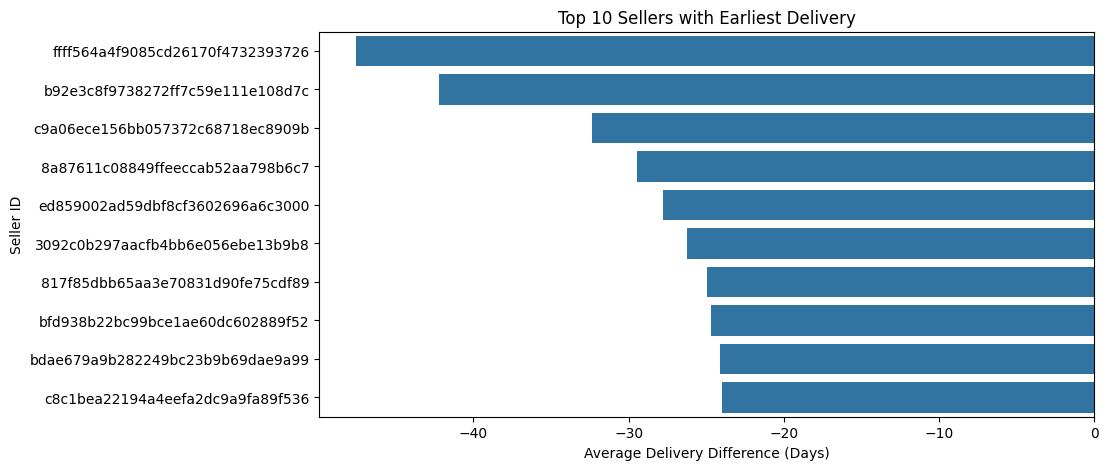

In [45]:
plt.figure(figsize=(10,5))

top10 = top_delivary_sellers.sort_values("avg_delay")

sns.barplot(
    x=top10["avg_delay"].dt.total_seconds()/(24*3600),
    y=top10.index
)

plt.title("Top 10 Sellers with Earliest Delivery")
plt.xlabel("Average Delivery Difference (Days)")
plt.ylabel("Seller ID")

plt.show()

Some sellers deliver orders significantly earlier than the estimated delivery date, with differences reaching more than 40 days, indicating possible estimation inaccuracies or outliers in the dataset.


# Customer Satisfaction Impact

## 1- Does a delay affect customer ratings?

In [46]:
orders_with_review=pd.merge(orders,review,on="order_id")
delay_with_review=orders_with_review.groupby("apply_SLA")['review_score'].mean()
delay_with_review

apply_SLA
False    2.348192
True     4.293578
Name: review_score, dtype: float64

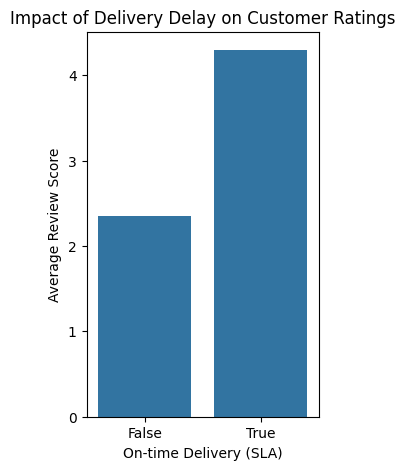

In [47]:
plt.figure(figsize=(3,5))
sns.barplot(x=delay_with_review.index,y=delay_with_review.values)

plt.xlabel("On-time Delivery (SLA)")
plt.ylabel("Average Review Score")
plt.title("Impact of Delivery Delay on Customer Ratings")

plt.show()

Delivery delays have a clear impact on customer satisfaction. Orders delivered on time (True) receive a much higher average rating (4.29), while delayed orders (False) receive significantly lower ratings (2.35). This shows that delivery performance strongly influences customer reviews.

# Root Cause Analysis

In [48]:
delay_orders=orders[orders["apply_SLA"]==False].copy()
delay_orders['order_status'].value_counts()

order_status
delivered      7834
shipped        1107
canceled        620
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

## 1- Filter data based on delay orders only [not canceled or unavailable]

In [49]:
delay_orders = orders[(~orders["apply_SLA"]) & (orders["order_status"].isin(["delivered","shipped","invoiced","processing","created","approved"]))].copy()
delay_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,org_to_carrier_time,carrier_to_customer_time,actual_arrival_time,apply_SLA,delivery_delay,estimated_delivery_time,delivery_Days,month
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,NaT,NaT,NaT,False,NaT,25 days 10:34:43,NaN,2017-04
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,17 days 13:45:54,3 days 04:33:43,20 days 18:19:37,False,11 days 22:23:46,8 days 19:55:51,20.0,2017-09
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,4 days 19:54:36,22 days 23:38:32,27 days 19:33:08,False,9 days 22:03:54,17 days 21:29:14,27.0,2018-02
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20,3 days 06:48:22,27 days 01:55:29,30 days 08:43:51,False,0 days 00:59:25,30 days 07:44:26,30.0,2018-02
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,18 days 20:52:56,14 days 21:45:18,33 days 18:38:14,False,7 days 18:59:23,25 days 23:38:51,33.0,2017-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99396,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16,12 days 18:37:54,5 days 06:21:26,18 days 00:59:20,False,5 days 00:03:26,13 days 00:55:54,18.0,2018-08
99397,0fa1fab1d7c1211c824596ed5e111e3c,7f3bd6c94d2daf7b6462d1a894a775b4,delivered,2018-03-13 21:48:57,2018-03-13 22:40:28,2018-03-14 19:27:23,2018-04-05 19:59:49,2018-04-02,0 days 20:46:55,22 days 00:32:26,22 days 21:19:21,False,3 days 19:59:49,19 days 01:19:32,22.0,2018-03
99423,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31,3 days 13:36:18,35 days 00:02:17,38 days 13:38:35,False,21 days 17:06:59,16 days 20:31:36,38.0,2017-10
99425,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,delivered,2018-03-21 19:47:18,2018-03-21 20:05:26,2018-03-22 21:11:58,2018-04-11 00:48:31,2018-04-09,1 days 01:06:32,19 days 03:36:33,20 days 04:43:05,False,2 days 00:48:31,18 days 03:54:34,20.0,2018-03


Around 11% of SLA violations are associated with orders that were never completed (e.g., canceled or unavailable), indicating that part of the delay issue is related to order fulfillment failures rather than delivery performance alone.

Approximately 11% of orders failed to meet the SLA requirements, **with about 9.6% representing actual delivery delays while the rest are related to order cancellations or product unavailability.**

1. **org_to_carrier_time** Time from order confirmation to order delivery to the shipping company
2. **carrier_to_customer_time** Time from when the shipping company receives the order until it is delivered to the customer
3. **actual_arrival_time** The total duration from order confirmation to its arrival to the customer.
4. **delivery_delay** The difference between the actual delivery time and the expected time.


## 2- Represent time distribution

In [50]:
orders["org_to_carrier_time"] = orders["org_to_carrier_time"].dt.total_seconds() / (24*3600)
orders["carrier_to_customer_time"] = orders["carrier_to_customer_time"].dt.total_seconds() / (24*3600)
orders["actual_arrival_time"] = orders["actual_arrival_time"].dt.total_seconds() / (24*3600)


In [51]:
for col in ["org_to_carrier_time","carrier_to_customer_time","actual_arrival_time"]:
    print(orders[col].describe())
    print()

count    97644.000000
mean         2.805038
std          3.549427
min       -171.219005
25%          0.875509
50%          1.818397
75%          3.580469
max        125.762569
Name: org_to_carrier_time, dtype: float64

count    96475.000000
mean         9.330547
std          8.760122
min        -16.096169
25%          4.099948
50%          7.099769
75%         12.029115
max        205.190972
Name: carrier_to_customer_time, dtype: float64

count    96462.000000
mean        12.130357
std          9.516863
min         -6.989653
25%          6.309910
50%          9.852263
75%         15.141282
max        208.500972
Name: actual_arrival_time, dtype: float64



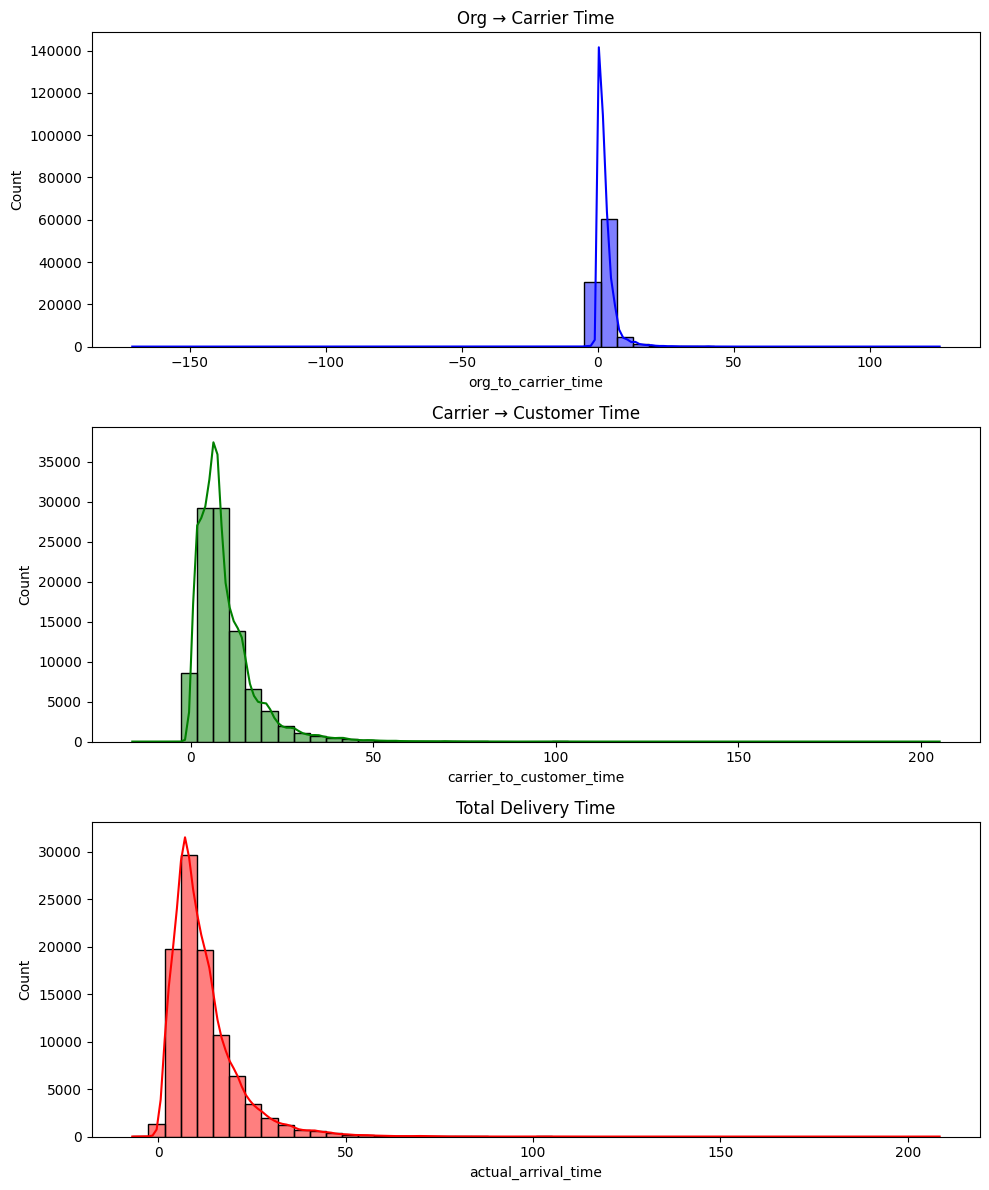

In [52]:

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

sns.histplot(orders["org_to_carrier_time"], bins=50, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Org → Carrier Time")

sns.histplot(orders["carrier_to_customer_time"], bins=50, kde=True, ax=axes[1], color="green")
axes[1].set_title("Carrier → Customer Time")

sns.histplot(orders["actual_arrival_time"], bins=50, kde=True, ax=axes[2], color="red")
axes[2].set_title("Total Delivery Time")

plt.tight_layout()
plt.show()

**1. Processing time (Org → Carrier) is relatively fast (~2–3 days) but contains inaccurate data (negative values).**

**2. Carrier → Customer is the main bottleneck (≈ 7–9 days median) and accounts for the majority of delivery time.**

**4. Total delivery time is ≈ 10–12 days, but there are very large extreme delays (up to 200+ days) → clear outliers/data issues.**

## 3- Clear outliers and negative values

In [53]:
for col in ["org_to_carrier_time","carrier_to_customer_time","actual_arrival_time"]:
    orders[col] = orders[col].clip( orders[col].quantile(0.01),orders[col].quantile(0.99))


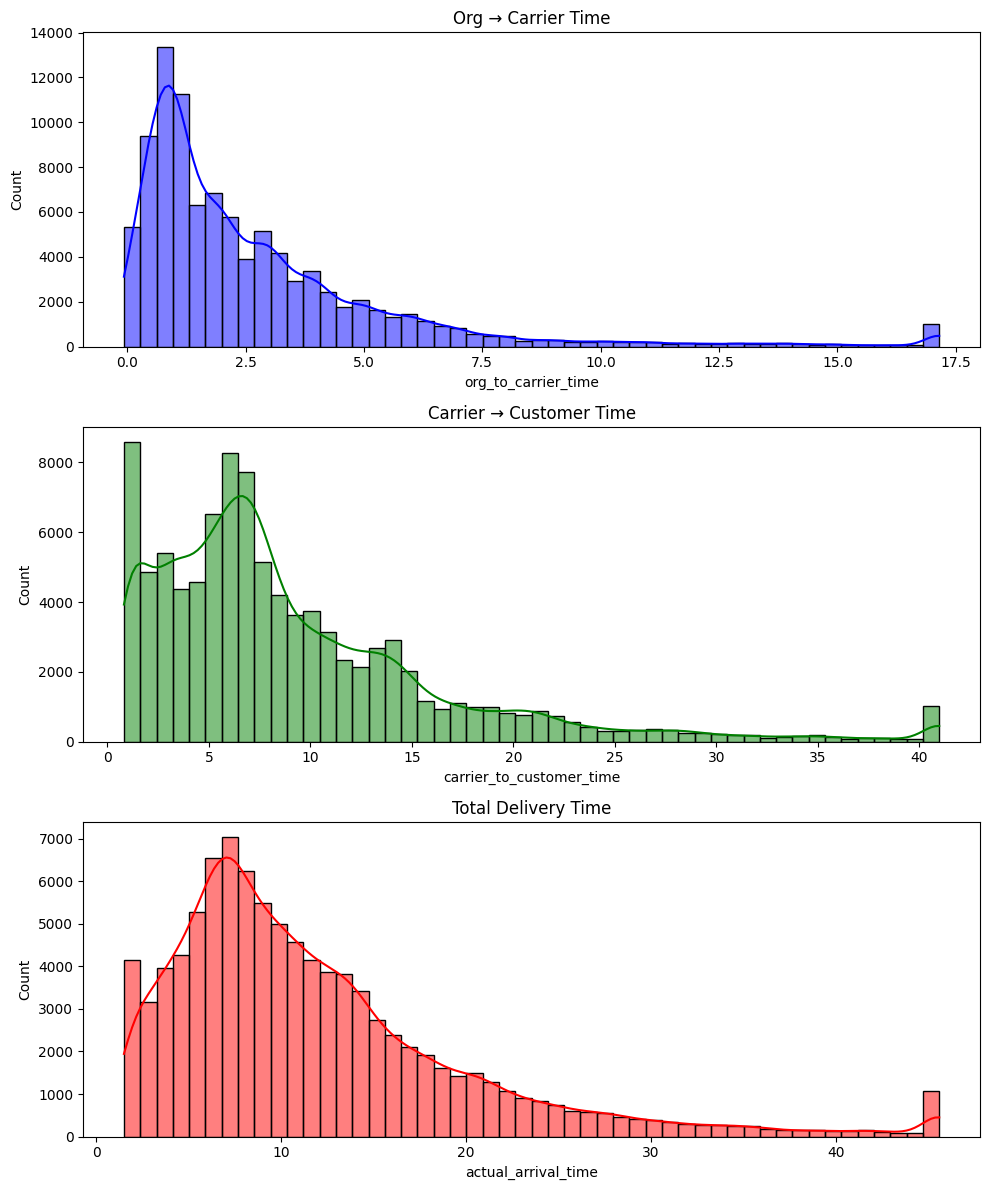

In [54]:

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

sns.histplot(orders["org_to_carrier_time"], bins=50, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Org → Carrier Time")

sns.histplot(orders["carrier_to_customer_time"], bins=50, kde=True, ax=axes[1], color="green")
axes[1].set_title("Carrier → Customer Time")

sns.histplot(orders["actual_arrival_time"], bins=50, kde=True, ax=axes[2], color="red")
axes[2].set_title("Total Delivery Time")

plt.tight_layout()
plt.show()

reason of most delay cause in duration [carrier to customer] why?
is reason by geolocation???

## 4- Distance between customers and seller

In [55]:
customer_geo = geolocation.groupby("geolocation_zip_code_prefix").first().reset_index()

customers = customers.merge(
    customer_geo,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

customers = customers.rename(columns={
    "geolocation_lat":"customer_lat",
    "geolocation_lng":"customer_lng"
})

seller_geo = geolocation.groupby("geolocation_zip_code_prefix").first().reset_index()

sellers = sellers.merge(
    seller_geo,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

sellers = sellers.rename(columns={
    "geolocation_lat":"seller_lat",
    "geolocation_lng":"seller_lng"
})

In [56]:
orders_items = orders.merge(items, on="order_id")

orders_items = orders_items.merge(
    customers[["customer_id","customer_lat","customer_lng"]],
    on="customer_id"
)

orders_items = orders_items.merge(
    sellers[["seller_id","seller_lat","seller_lng"]],
    on="seller_id"
)

In [57]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # radius of earth km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R*c

In [58]:
orders_items = orders_items.loc[:, ~orders_items.columns.duplicated()]

In [59]:
orders_items["distance_km"] = haversine(
    orders_items["seller_lat"],
    orders_items["seller_lng"],
    orders_items["customer_lat"],
    orders_items["customer_lng"]
)



In [60]:
orders_items["distance_km"].head()

0      18.063837
1     856.292580
2     514.130333
3    1822.800366
4      30.174037
Name: distance_km, dtype: float64

In [61]:
orders_items[["distance_km","carrier_to_customer_time"]].corr()

,distance_km,carrier_to_customer_time
distance_km,1.000000,0.470194
carrier_to_customer_time,0.470194,1.000000


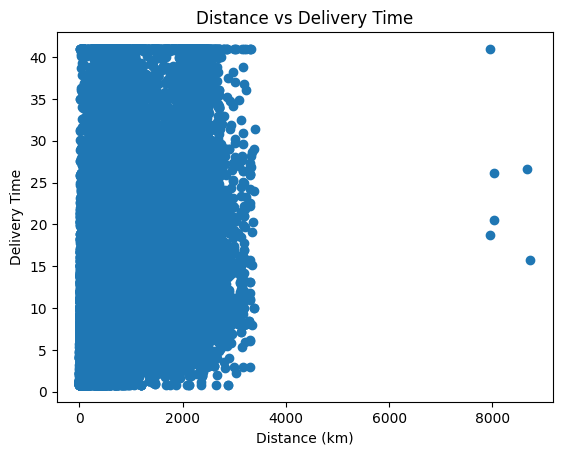

In [62]:
import matplotlib.pyplot as plt

plt.scatter(
    orders_items["distance_km"],
    orders_items["carrier_to_customer_time"]
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")

plt.show()

Most deliveries occur within 3000 km.
There is a moderate positive relationship between distance and delivery time, indicating that longer distances tend to increase delivery duration, although other factors also influence delivery speed.



**There are points 8000 km apart.**
**This is strange because Brazil is only about 4300 km wide.**

## 5- remove Outliers

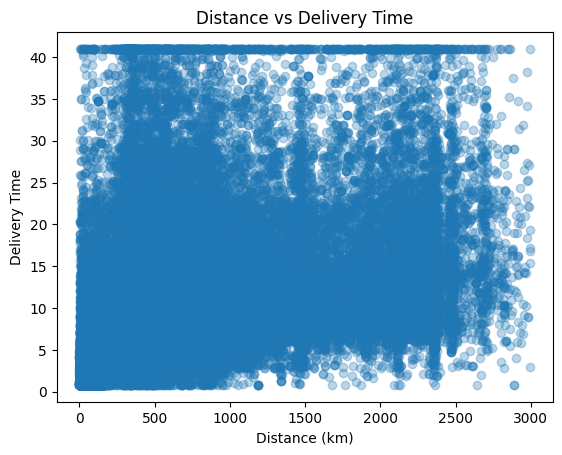

In [63]:
filtered = orders_items[orders_items["distance_km"] < 3000]

plt.scatter(
    filtered["distance_km"],
    filtered["carrier_to_customer_time"],
    alpha=0.3
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")

plt.show()